## Checking of Energy Minimization

In [1]:
import os
data_dir = "/home/daneel/gitrepos"
data_dir = os.path.join(data_dir, "gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulations_cg/simulation_cg_notrans_inv")
os.chdir(data_dir)


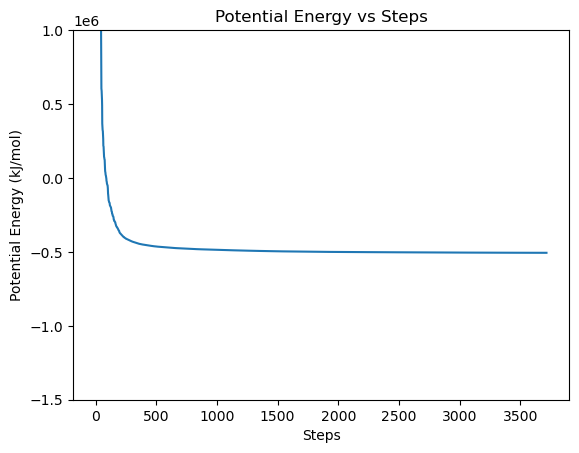

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

## Production PP

First, let's test to ensure that the concatenation worked.

In [3]:
import MDAnalysis as mda


u = mda.Universe("md.tpr", "traj_nojump.xtc")

/usr/local/lib/python3.12/site-packages/openmm/__init__.py:16: SyntaxWarning: invalid escape sequence '\p'
  os.environ['PATH'] = '%(lib)s;%(lib)s\plugins;%(path)s' % {
/usr/local/lib/python3.12/site-packages/openmm/openmm.py:11825: SyntaxWarning: invalid escape sequence '\S'
  match = re.search("<([^?]\S*)", inputString)
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbstructure.py:1078: SyntaxWarning: invalid escape sequence '\.'
  if not re.match("pdb.%2s.\.ent\.gz" % subdir , pdb_file):
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbstructure.py:1089: SyntaxWarning: invalid escape sequence '\.'
  if not re.match("pdb.%2s.\.ent\.gz" % subdir , pdb_file):
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbx/reader/PdbxReader.py:347: SyntaxWarning: invalid escape sequence '\S'
  "(?:_(.+?)[.](\S+))"               "|"  # _category.attribute
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbx/reader/PdbxReader.py:349: SyntaxWarning:

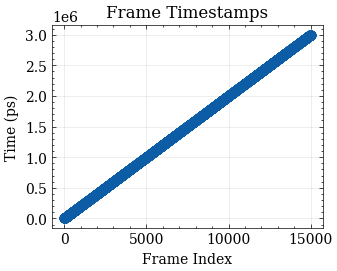

Min dt: 200.00 ps, Max dt: 200.00 ps
Monotonically increasing: True
Total frames: 15001, Time range: 0.00 – 3000000.00 ps


In [4]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
# First, check the timestamps for each frame
timestamps = [ts.time for ts in u.trajectory]  # in ps

plt.plot(timestamps, marker="o", linestyle="")
plt.title("Frame Timestamps")
plt.xlabel("Frame Index")
plt.ylabel("Time (ps)")
plt.grid(True, alpha=0.3)
plt.show()

# Check if timestamps are monotonically increasing (expected after correct trjcat)
import numpy as np
diffs = np.diff(timestamps)
print(f"Min dt: {diffs.min():.2f} ps, Max dt: {diffs.max():.2f} ps")
print(f"Monotonically increasing: {np.all(diffs > 0)}")
print(f"Total frames: {len(timestamps)}, Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} ps")

The concatenation succeeded!

In [5]:
corrected_times = np.array(timestamps)
print(f"Mapped Time Range: {corrected_times[0]:.0f} to {corrected_times[-1]:.0f} ps")

Mapped Time Range: 0 to 3000000 ps


In [6]:
import os
import numpy as np
import MDAnalysis as mda
from multiprocessing import Pool, cpu_count
from functools import partial
from MDAnalysis.analysis import rms
from tqdm.notebook import tqdm

# --- Config ---
tpr_file = os.path.join(data_dir, "md.tpr")
xtc_file = os.path.join(data_dir, "traj_nojump.xtc")

# Clean selections
ku04_sel = "resname ALA ARG ASN ASP CYS GLU GLN GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL"
memb_sel = "resname DVPE POPG POPE DOPE TOCL and name PO4"

# --- Define Reference from Unwrapped Frame 0 ---
u = mda.Universe(tpr_file, xtc_file)
u.trajectory[0] # Load first frame directly without wrapping transformations
ref_memb = u.select_atoms(memb_sel).positions.copy()
ref_ku04 = u.select_atoms(ku04_sel).positions.copy()

# --- Split trajectory into blocks (one per core) ---
n_jobs = min(cpu_count(), 8)
n_frames = u.trajectory.n_frames
n_fpb = n_frames // n_jobs

blocks = [range(i * n_fpb, (i + 1) * n_fpb) for i in range(n_jobs - 1)]
blocks.append(range((n_jobs - 1) * n_fpb, n_frames))
print(f"Frames: {n_frames} | Cores: {n_jobs} | ~{n_fpb} frames/block")

# --- Clean Worker function (No Transformations) ---
def rmsd_block(block_frames, tpr_file, xtc_file, memb_sel, ku04_sel, ref_memb, ref_ku04):
    """Each worker loads its own Universe and iterates its slice sequentially."""
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    
    u_w = mda.Universe(tpr_file, xtc_file)
    memb_w = u_w.select_atoms(memb_sel)
    ku04_w = u_w.select_atoms(ku04_sel)
    
    res_memb, res_ku04 = [], []
    
    # Slice step handles sequential random access safely 
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        # superposition=True handles all translation/rotation alignment mathematically
        res_memb.append(rms.rmsd(memb_w.positions, ref_memb, superposition=True))
        res_ku04.append(rms.rmsd(ku04_w.positions, ref_ku04, superposition=True))
        
    u_w.trajectory.close() 
    return res_memb, res_ku04

# --- Run in parallel ---
run_block = partial(
    rmsd_block, 
    tpr_file=tpr_file, 
    xtc_file=xtc_file, 
    memb_sel=memb_sel, 
    ku04_sel=ku04_sel, 
    ref_memb=ref_memb, 
    ref_ku04=ref_ku04
)

with Pool(n_jobs) as pool:
    block_results = list(tqdm(pool.imap(run_block, blocks), total=n_jobs, desc="Blocks", unit="block"))

# --- Combine in order ---
rmsd_memb = [v for memb_res, _ in block_results for v in memb_res]
rmsd_ku04 = [v for _, ku04_res in block_results for v in ku04_res]

# Convert to nanometers if plotting in nm (MDAnalysis outputs in Angstroms natively)
rmsd_memb_nm = np.array(rmsd_memb) / 10.0
rmsd_ku04_nm = np.array(rmsd_ku04) / 10.0

print(f"Done. {len(rmsd_memb_nm)} clean RMSD values computed.")

Frames: 15001 | Cores: 8 | ~1875 frames/block


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. 15001 clean RMSD values computed.


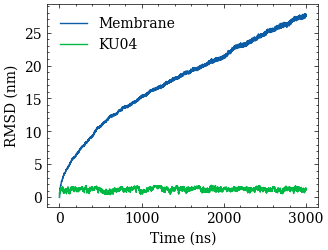

In [7]:
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False

plt.plot(corrected_times/1000, np.array(rmsd_memb)/10, label="Membrane")
plt.plot(corrected_times/1000, np.array(rmsd_ku04)/10, label="KU04")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
#plt.grid(True, alpha=0.6)
plt.show()

## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

In [8]:
# Selection for all phosphorus atoms in the membrane. When using martini CG, try replacing with "name PO4" for the phosphate beads
phosphorus_sel = "resname DVPE POPG POPE DOPE TOCL and name PO4"

def p_depth_block(block_frames, tpr_file, xtc_file, memb_sel, p_sel):
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans
    u_w = mda.Universe(tpr_file, xtc_file)
    memb_w = u_w.select_atoms(memb_sel)
    p_w = u_w.select_atoms(p_sel)
    
    
    z_p_upper, z_p_lower, z_mid = [], [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        mid = memb_w.center_of_mass()[2]
        p_pos = p_w.positions[:, 2]
        
        # Split P atoms into upper and lower based on midplane
        z_p_upper.append(p_pos[p_pos > mid].mean())
        z_p_lower.append(p_pos[p_pos < mid].mean())
        z_mid.append(mid)
        
    u_w.trajectory.close()
    return z_p_upper, z_p_lower, z_mid

# Run in parallel (reuse your blocks and n_jobs)
run_p = partial(p_depth_block, tpr_file=tpr_file, xtc_file=xtc_file,
                memb_sel=memb_sel, p_sel=phosphorus_sel)

with Pool(n_jobs) as pool:
    p_results = list(tqdm(pool.imap(run_p, blocks), total=n_jobs, desc="P-depth"))

# Average distances from midplane
dz_p_upper = np.array([v for r in p_results for v in r[0]]) - np.array([v for r in p_results for v in r[2]])
dz_p_lower = np.array([v for r in p_results for v in r[1]]) - np.array([v for r in p_results for v in r[2]])

print(f"Verified Phosphorus Planes: {dz_p_upper.mean():.2f} Å and {dz_p_lower.mean():.2f} Å")

P-depth:   0%|          | 0/8 [00:00<?, ?it/s]

Verified Phosphorus Planes: 20.99 Å and -20.59 Å


### Get z-COM of peptide

In [9]:
import numpy as np
from tqdm.notebook import tqdm
from functools import partial
from multiprocessing import Pool

def depth_block(block_frames, tpr_file, xtc_file, memb_sel, ku04_sel):
    """Worker: z-COM of KU04 and membrane midplane per frame."""
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans

    u_w     = mda.Universe(tpr_file, xtc_file)
    memb_w  = u_w.select_atoms(memb_sel)
    ku04_w  = u_w.select_atoms(ku04_sel)

    
    z_ku04, z_mid = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        z_mid.append(memb_w.center_of_mass()[2])
        z_ku04.append(ku04_w.center_of_mass()[2])
        
    u_w.trajectory.close()
    return z_ku04, z_mid

# Prepare partial function for parallel execution
run_depth = partial(depth_block,
                    tpr_file=tpr_file, xtc_file=xtc_file,
                    memb_sel=memb_sel, ku04_sel=ku04_sel)

print(f"Computing penetration depth on {n_jobs} cores …")
with Pool(n_jobs) as pool:
    depth_results = list(tqdm(pool.imap(run_depth, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# Combine results
z_ku04 = np.array([v for r in depth_results for v in r[0]])
z_mid  = np.array([v for r in depth_results for v in r[1]])

# Depth relative to membrane midplane
# (positive = upper leaflet side, negative = lower leaflet side)
dz_ku04 = z_ku04 - z_mid

print(f"Done. Mean KU04 depth relative to midplane: {dz_ku04.mean():.1f} Å")

Computing penetration depth on 8 cores …


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. Mean KU04 depth relative to midplane: 44.0 Å


### Plot z-COM relative to membrane COM and headgroup planes

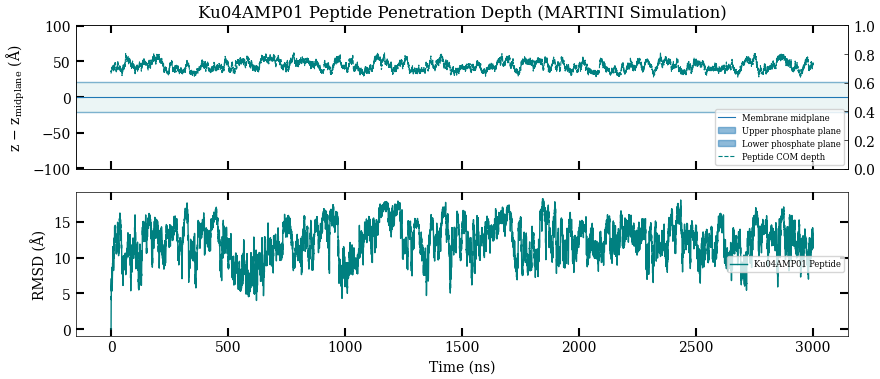

In [11]:
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
t_ns = corrected_times / 1000

fig, (ax_up, ax_down) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, tight_layout=True, gridspec_kw={'height_ratios': [1, 1]})


ax = ax_up  # Use the lower axis for plotting
# Mark the membrane center line
ax.axhline(0, color="tab:blue", lw=0.8, label="Membrane midplane")

# UPDATED: Verified Phosphorus headgroup planes
upper_p = dz_p_upper.mean()
lower_p = dz_p_lower.mean()

upper_p_std = dz_p_upper.std()
lower_p_std = dz_p_lower.std()
ax.axhspan(upper_p - upper_p_std, upper_p + upper_p_std, alpha=0.5, color="tab:blue", label="Upper phosphate plane")
ax.axhspan(lower_p - lower_p_std, lower_p + lower_p_std, alpha=0.5, color="tab:blue", label="Lower phosphate plane")

ax.axhspan(lower_p, upper_p, alpha=0.08, color="teal")

# Plot the Peptide depth
ax.plot(t_ns, dz_ku04, lw=0.8, color="teal", label="Peptide COM depth", ls="--")

ax.set_title("Ku04AMP01 Peptide Penetration Depth (MARTINI Simulation)")
ax.set_ylabel(r"z − z$_{\text{midplane}}$ (Å)")
ax.minorticks_off()
ax_ylim = np.sort(list(ax.get_ylim())) * 1.5
ax.set_ylim(-ax_ylim[1], ax_ylim[1])

# Add a secondary y-axis to show acceleration of penetration depth (optional)
ax2 = ax.twinx()
ax2.minorticks_off()

# Get derivativs after spline interpolation
spline = UnivariateSpline(t_ns, dz_ku04, s=0)
dz_ku04_dt = spline.derivative(n=1)(t_ns)
dz_ku04_d2t = spline.derivative(n=2)(t_ns)

# Calculate mean and std over only the last 50% of the simulation
last_50_percent_mask = t_ns >= (t_ns[-1] - 0.5 * (t_ns[-1] - t_ns[0]))
mean_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].mean()
std_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].std()


#ax2.plot(t_ns, dz_ku04_d2t, lw=0.8, color="tab:green", alpha=0.5, label=f"z-Acceleration: Mean (last 50%) ({mean_accel_last_50_percent:.2f} ± {std_accel_last_50_percent:.2f}) Å/ns²", ls="-.")
#ax2.axhline(dz_ku04_d2t.mean(), color="gray", lw=0.8, ls="--", alpha=0.1)
#ax2.set_ylabel(r"Acceleration (Å/ns²)")
# Align the zeros of ax and ax2
#ax2_ylim = np.sort(list(ax2.get_ylim()))
#ax2.set_ylim(-ax2_ylim[1], ax2_ylim[1])

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax2.legend(lines + lines2, labels + labels2, loc="lower right", fontsize=6, frameon=True, fancybox=True)

ax.legend(lines , labels, loc="lower right", fontsize=6, frameon=True, fancybox=True)
ax = ax_down
ax.minorticks_off()
ax.set_xlabel("Time (ns)")
#ax.plot(t_ns, np.array(rmsd_memb), label="Membrane", alpha=0.8, color="tab:blue")
ax.plot(t_ns, np.array(rmsd_ku04), label="Ku04AMP01 Peptide", color="teal")
ax.set_ylabel("RMSD (Å)")
ax.legend(loc="center right", fontsize=6, frameon=True, fancybox=True)

for ax in [ax_up, ax_down]:#, ax2]:
    ax.tick_params(axis='both', which='major', length=6, width=1.5)


plt.show()

Nope. nada. zilch.